# Convergência Estatística Aplicada à Precificação de Opções via Modelo Binomial

Este projeto usa a **precificação de uma opção de compra europeia** (via modelo binomial e simulação de Monte Carlo) como uma forma de demostrar três teoremas fundamentais da probabilidade:

- **Lei Fraca dos Grandes Números (LFGN)** — convergência em probabilidade
- **Lei Forte dos Grandes Números (LFGN forte)** — convergência quase certa
- **Teorema Central do Limite (TLC)** — incluindo o Teorema de De Moivre–Laplace

Os parâmetros do modelo são estimados a partir de **dados reais de mercado**: preço e volatilidade da ação PETR4 (via Yahoo Finance) e taxa livre de risco Selic (via API do Banco Central).

**Roteiro:**
| Módulo | Conteúdo |
|---|---|
| 0 | Coleta de dados, parâmetros e funções base |
| 1 | LFGN — convergência em probabilidade |
| 2 | LFGN forte — convergência quase certa |
| 3 | TLC — De Moivre–Laplace e intervalos de confiança |
| 4 | Convergência do Binomial para Black–Scholes |


## Bibliotecas

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, norm
import yfinance as yf
import requests as rt
import math as M

plt.style.use('seaborn-v0_8-whitegrid')

## Módulo 0 — Coleta de dados, parâmetros e funções base

Antes de simular, precisamos de seis parâmetros do modelo binomial. Três vêm de dados do mercado ($S_0$, $\sigma$, $r$) e três são escolhas de cenário ($K$, $T$, $n_{steps}$).

### Download do histórico de preços da PETR4 (2 anos)

In [40]:
dados = yf.download("PETR4.SA", period="2y")
dados[['Close']].tail()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,PETR4.SA
Date,
2026-07-31,43.419998
2026-08-03,43.049999
2026-08-04,42.500000
2026-08-05,41.930000
2026-08-06,42.189999


### Volatilidade anualizada ($\sigma$)

A volatilidade histórica é o desvio padrão dos log-retornos diários, anualizado por $\sqrt{252}$

In [41]:
close = dados['Close'].squeeze()
razao = close / close.shift(1)          # razão entre fechamento de hoje e o do dia anterior
log_retorno = np.log(razao).dropna()    # log-retorno diário 

dp = log_retorno.std()                  # desvio padrão amostral 
dp_anual = dp * np.sqrt(252)            # volatilidade anualizada

print(f"Volatilidade anualizada: {dp_anual:.4f}")

Volatilidade anualizada: 0.2451


### Taxa livre de risco ($r$) — Selic via API do Banco Central

Usando a série 11 (Selic) do Banco Central.


In [42]:
codigo = 11
n = 1
url = f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados/ultimos/{n}?formato=json'
resposta = rt.get(url)
selic = resposta.json()
r = float(selic[0]['valor'])            

print(f"Taxa Selic (r): {r:.4f}  ({selic[0]['data']})")

Taxa Selic (r): 0.0525  (05/08/2026)


### Parâmetros de cenário

- $S_0$: preço atual da ação
- $K$: preço de exercício (strike), escolhido igual a $S_0$ arredondado.
- $T$: tempo até o vencimento, em anos.
- $n_{steps}$: número de passos da árvore binomial

In [43]:
s0 = close.iat[-1]        # preço atual da ação
strike = round(s0)        # preço de exercício 
T = 0.25                  # tempo de vencimento
n_steps = 200             # número de passos da árvore binomial

print(f"S0 = {s0:.2f},  K = {strike},  T = {T},  n_steps = {n_steps}")

S0 = 42.19,  K = 42,  T = 0.25,  n_steps = 200


### Parâmetros derivados: $u$, $d$, $p$

A cada passo de tamanho $\Delta t = T/n_{steps}$, o preço sobe por um fator $u$ ou desce por $d$, com probabilidade neutra ao risco $p$:

$$u = e^{\sigma\sqrt{\Delta t}}, \qquad d = \frac{1}{u}, \qquad p = \frac{e^{r\Delta t} - d}{u - d}$$

In [44]:
def outputs(vol):
    deltaT = T / n_steps
    u = M.exp(vol * M.sqrt(deltaT))
    d = 1 / u
    p = (M.exp(r * deltaT) - d) / (u - d)
    return u, d, p

u, d, p = outputs(dp_anual)
print(f"u = {u:.6f} | d = {d:.6f} | p = {p:.6f}")

u = 1.008704 | d = 0.991371 | p = 0.501622


### Função de simulação de uma trajetória



$$S_n = S_0 \cdot u^k \cdot d^{\,n_{steps}-k}, \qquad \text{payoff} = \max(S_n - K,\ 0)$$

In [45]:
def simulacao(s, P, sub, des, si, K_strike):
    k = np.random.binomial(s, P)                 # número de subidas
    Sn = si * (sub ** k) * (des ** (s - k))      # preço final da ação
    payoff = max(Sn - K_strike, 0)               # payoff da opção de compra
    return Sn, k, payoff

Sn, k, payoff = simulacao(n_steps, p, u, d, s0, strike)
print(f"Sn = {Sn:.4f} , k = {k} , payoff = {payoff:.4f}")

Sn = 40.0523 , k = 97 , payoff = 0.0000


### Preço teórico (fórmula fechada binomial)

Somando sobre **todos** os cenários possíveis de $k$ (de 0 a $n_{steps}$), ponderados pela sua probabilidade exata, obtemos o valor esperado do payoff que, descontado, é o preço justo $C$:

$$C = e^{-rT} \sum_{k=0}^{n} \binom{n}{k} p^k (1-p)^{n-k} \max(S_0 u^k d^{n-k} - K,\ 0)$$


In [46]:
esperanca = 0
for l in range(n_steps + 1):                        # percorre TODOS os cenários k = 0..n_steps
    probk = binom.pmf(l, n_steps, p)                # probabilidade de exatamente l subidas
    Snk = s0 * (u ** l) * (d ** (n_steps - l))      # preço da ação nesse cenário
    payoffk = max(Snk - strike, 0)                  # payoff nesse cenário
    esperanca += probk * payoffk                    # contribuição ponderada

def teorico(j, t, e):
    return M.exp(-j * t) * e                        
C = teorico(r, T, esperanca)
print(f"Preço teórico: {C:.4f}")

Preço teórico: 2.4349


## Módulo 1 — Lei Fraca dos Grandes Números (LFGN)

A LFGN afirma que a média amostral converge **em probabilidade** para a esperança: para qualquer $\varepsilon$ > 0, a probabilidade de a estimativa $\hat{C}_N$ estar longe do valor real $C$ tende a zero conforme $N$ cresce.

$$P\left(|\hat{C}_N - C| > \varepsilon\right) \xrightarrow{N\to\infty} 0$$



In [47]:
simulacao_N = [10, 100, 1000, 10000]   # tamanhos de amostra a testar
m_repeticao = 1000                      # numero de estimativas independentes por N
epsilon = 0.20                          # margem de erro

def estimador_preco(N):
    payoff_N = []
    for _ in range(N):
        _, _, pyf = simulacao(n_steps, p, u, d, s0, strike)
        payoff_N.append(pyf)
    return M.exp(-r * T) * np.mean(payoff_N)   # estimativa Ĉ_N


resultados = {}
for N in simulacao_N:
    resultados[N] = [estimador_preco(N) for _ in range(m_repeticao)]

margem_erro = {}
for N in simulacao_N:
    erros = np.sum(np.abs(np.array(resultados[N]) - C) > epsilon)
    margem_erro[N] = erros / m_repeticao



### Gráfico — a probabilidade de erro cai para zero

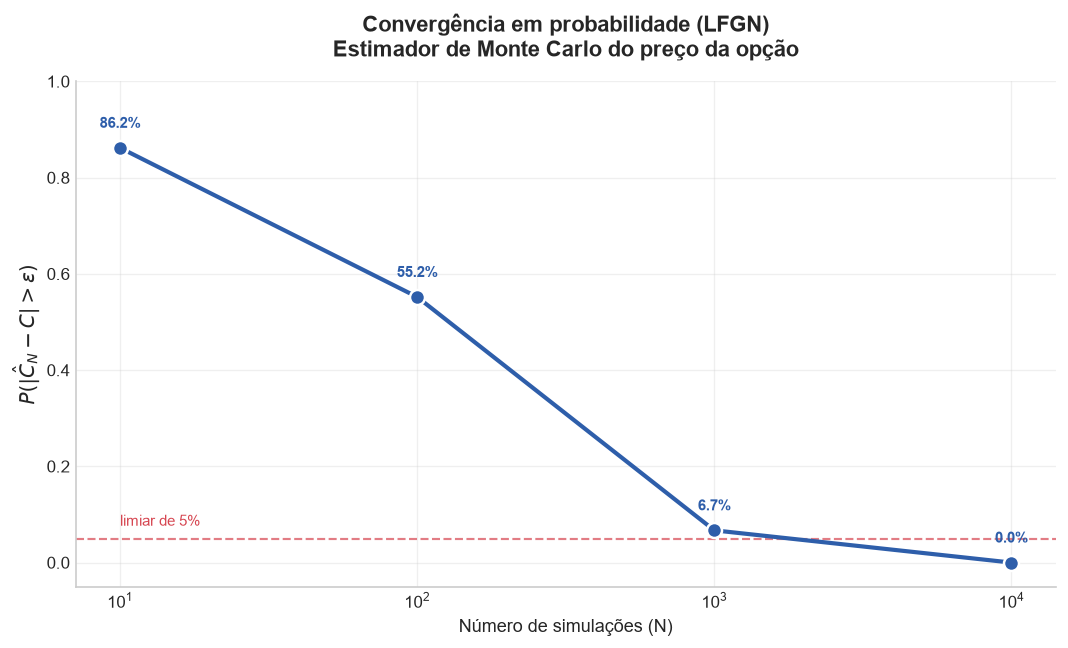

In [48]:
x = list(margem_erro.keys())
y = list(margem_erro.values())

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=120)
ax.plot(x, y, marker='o', markersize=9, linewidth=2.5, color='#2E5EAA',
        markerfacecolor='#2E5EAA', markeredgecolor='white', markeredgewidth=1.5, zorder=3)

ax.axhline(y=0.05, color='#D64550', linestyle='--', linewidth=1.3, alpha=0.7, zorder=1)
ax.text(x[0], 0.07, 'limiar de 5%', color='#D64550', fontsize=9, va='bottom')

for xi, yi in zip(x, y):
    ax.annotate(f'{yi*100:.1f}%', xy=(xi, yi), xytext=(0, 12),
                textcoords='offset points', ha='center', fontsize=9,
                fontweight='bold', color='#2E5EAA')

ax.set_xscale('log')
ax.set_xlabel('Número de simulações (N)', fontsize=11)
ax.set_ylabel(r'$P(|\hat{C}_N - C| > \varepsilon)$', fontsize=12)
ax.set_title('Convergência em probabilidade (LFGN)\nEstimador de Monte Carlo do preço da opção',
             fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-0.05, 1.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Módulo 2 — Lei Forte dos Grandes Números (convergência quase certa)

A lei forte dos grandes números, diz que dada uma sequencia de variaveis aleatorias independentes e com distribuição indentica, a media amostral converge certamente para 1

$$P\left(\lim_{n\to\infty} \hat{C}_n = C\right) = 1$$


In [49]:
c = 100000  

payoff_soma = [simulacao(n_steps, p, u, d, s0, strike)[2] for _ in range(c)]

soma = np.cumsum(payoff_soma)        
deno = np.arange(1, c + 1)          
Xn = (soma / deno) * M.exp(-r * T)   

print(f"Estimativa após 1 simulação:      {Xn[0]:.4f}")
print(f"Estimativa após {c} simulações:  {Xn[-1]:.4f}")
print(f"Preço teórico (C):                {C:.4f}")

Estimativa após 1 simulação:      0.0000
Estimativa após 100000 simulações:  2.4376
Preço teórico (C):                2.4349


### Gráfico — múltiplas trajetórias convergindo para C

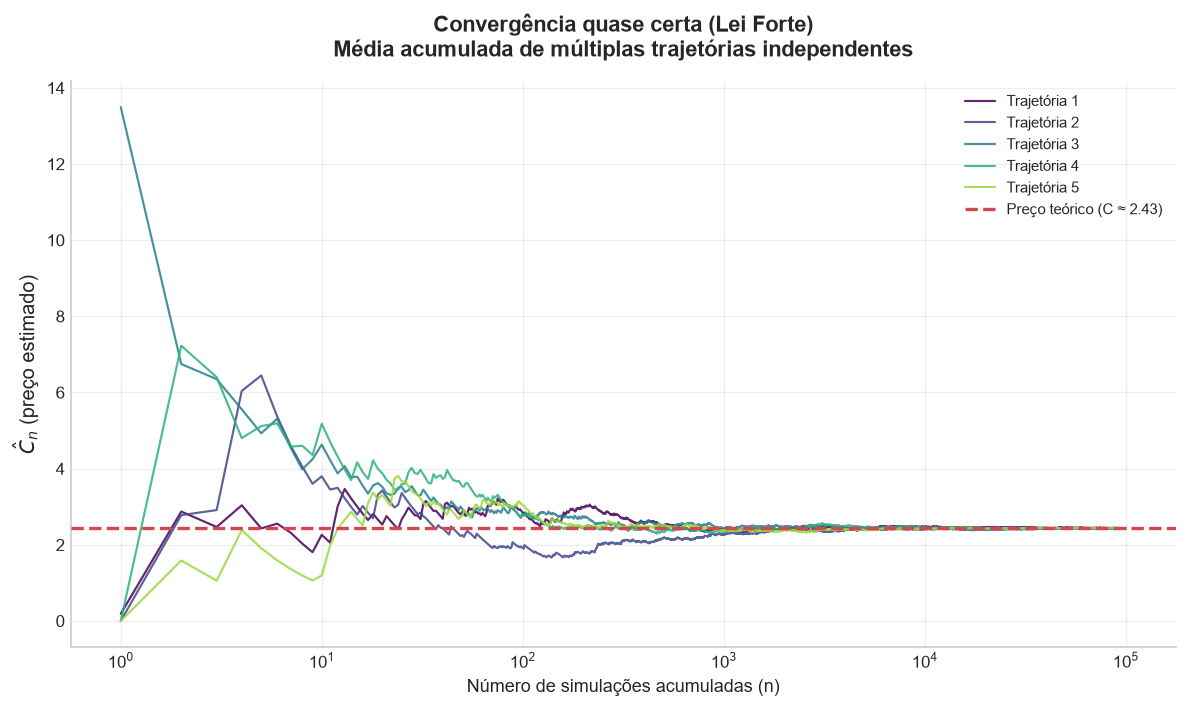

In [50]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

n_trajetorias = 5
cores = plt.cm.viridis(np.linspace(0, 0.85, n_trajetorias))

for idx in range(n_trajetorias):
    payoff_traj = [simulacao(n_steps, p, u, d, s0, strike)[2] for _ in range(c)]
    soma = np.cumsum(payoff_traj)
    Xn_traj = (soma / deno) * M.exp(-r * T)
    ax.plot(deno, Xn_traj, linewidth=1.3, alpha=0.85, color=cores[idx], label=f'Trajetória {idx+1}')

ax.axhline(y=C, color='#D64550', linestyle='--', linewidth=2,
           label=f'Preço teórico (C ≈ {C:.2f})', zorder=5)

ax.set_xscale('log')
ax.set_xlabel('Número de simulações acumuladas (n)', fontsize=11)
ax.set_ylabel(r'$\hat{C}_n$ (preço estimado)', fontsize=12)
ax.set_title('Convergência quase certa (Lei Forte)\nMédia acumulada de múltiplas trajetórias independentes',
             fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Módulo 3 — Teorema Central do Limite (TLC)

O TLC aparece em dois níveis neste projeto.

### Nível 1 — Teorema de De Moivre–Laplace
A distribuição Binomial (o número de subidas $k$), quando padronizada, converge para a Normal padrão conforme $n_{steps}$ cresce:

$$Z = \frac{k - np}{\sqrt{np(1-p)}} \xrightarrow{d} N(0,1)$$

In [51]:
steps = [10, 50, 100, 500, 1000, 5000]   # passos a serem testados
n_amostras = 100000                       

k_variados = {}
for g in steps:
    sort = np.random.binomial(g, p, size=n_amostras)         
    z = (sort - g * p) / M.sqrt(g * p * (1 - p))              
    k_variados[g] = z



#### Gráfico — a Binomial padronizada vira Normal

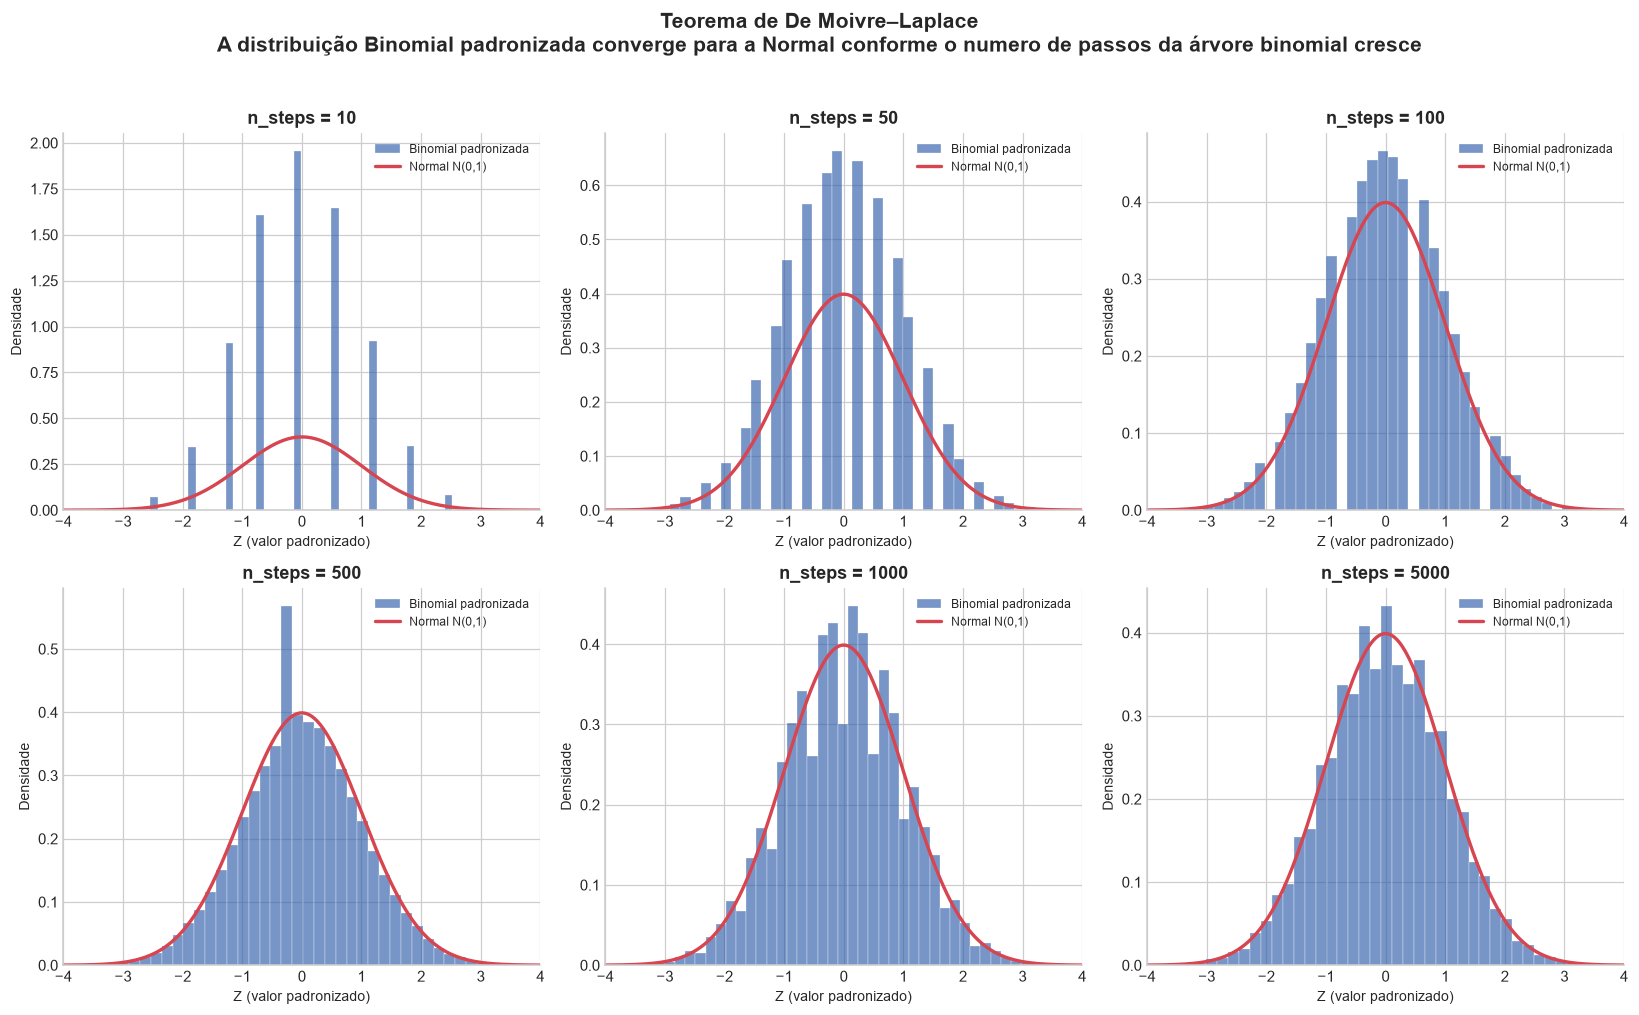

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), dpi=110)
axes = axes.flatten()

x = np.linspace(-4, 4, 300)
normal_pdf = norm.pdf(x)

for idx, g in enumerate(steps):
    ax = axes[idx]
    ax.hist(k_variados[g], bins=50, density=True, color='#2E5EAA', alpha=0.65,
            edgecolor='white', linewidth=0.3, label='Binomial padronizada')
    ax.plot(x, normal_pdf, color='#D64550', linewidth=2.2, label='Normal N(0,1)')
    ax.set_title(f'n_steps = {g}', fontsize=12, fontweight='bold')
    ax.set_xlim(-4, 4)
    ax.set_xlabel('Z (valor padronizado)', fontsize=9)
    ax.set_ylabel('Densidade', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Teorema de De Moivre–Laplace\nA distribuição Binomial padronizada converge para a Normal conforme o numero de passos da árvore binomial cresce',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Nível 2 — TLC aplicado ao estimador de Monte Carlo



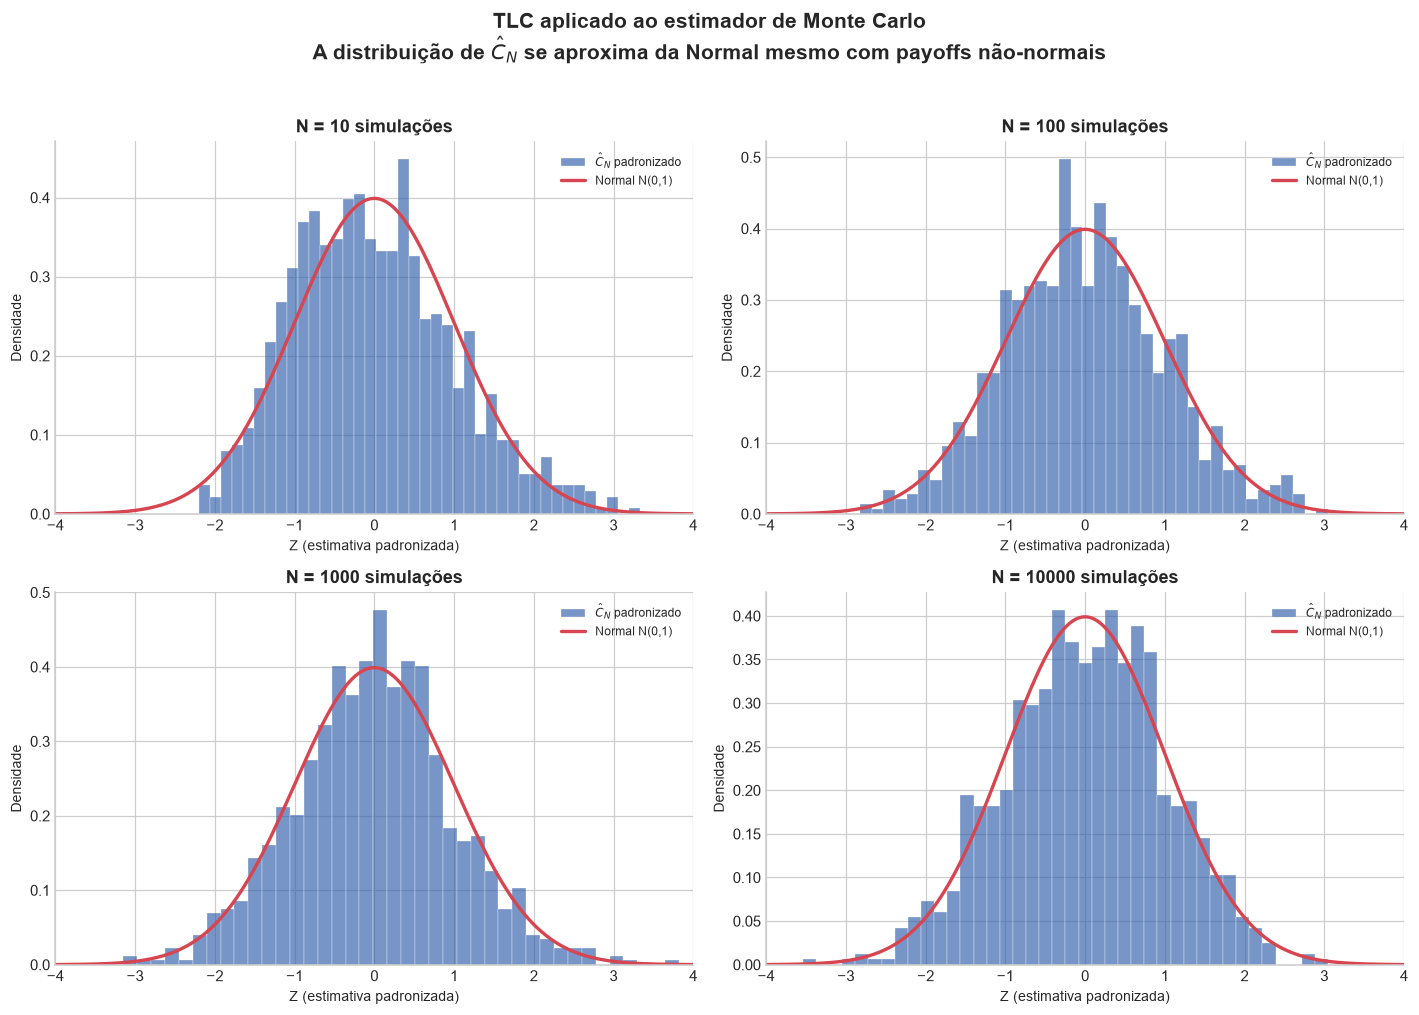

In [53]:

Cn_padronizado = {}
for N in simulacao_N:
    arr = np.array(resultados[N])
    Cn_padronizado[N] = (arr - arr.mean()) / arr.std()

fig, axes = plt.subplots(2, 2, figsize=(13, 9), dpi=110)
axes = axes.flatten()
x = np.linspace(-4, 4, 300)
normal_pdf = norm.pdf(x)

for idx, N in enumerate(simulacao_N):
    ax = axes[idx]
    ax.hist(Cn_padronizado[N], bins=40, density=True, color='#2E5EAA', alpha=0.65,
            edgecolor='white', linewidth=0.3, label=r'$\hat{C}_N$ padronizado')
    ax.plot(x, normal_pdf, color='#D64550', linewidth=2.2, label='Normal N(0,1)')
    ax.set_title(f'N = {N} simulações', fontsize=12, fontweight='bold')
    ax.set_xlim(-4, 4)
    ax.set_xlabel('Z (estimativa padronizada)', fontsize=9)
    ax.set_ylabel('Densidade', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('TLC aplicado ao estimador de Monte Carlo\n'
             r'A distribuição de $\hat{C}_N$ se aproxima da Normal mesmo com payoffs não-normais',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Intervalos de confiança e validação da cobertura



$$\hat{C}_N \pm 1{,}96 \cdot \frac{\hat{\sigma}}{\sqrt{N}}$$


In [54]:
def estimador_com_IC(N):
    payoffs = []
    for _ in range(N):
        _, _, pyf = simulacao(n_steps, p, u, d, s0, strike)
        payoffs.append(pyf)

    payoffs_desc = np.array(payoffs) * M.exp(-r * T) 
    Cn = payoffs_desc.mean()                            
    desvio = payoffs_desc.std()                         
    margem = 1.96 * desvio / np.sqrt(N)                
    return Cn, Cn - margem, Cn + margem


N_fixo = 1000
M_cobertura = 1000
acertos = 0
intervalos = []

for _ in range(M_cobertura):
    estimativa, inf, sup = estimador_com_IC(N_fixo)
    intervalos.append((estimativa, inf, sup))
    if inf <= C <= sup:
        acertos += 1

cobertura_empirica = acertos / M_cobertura
print(f"Cobertura empírica:  {cobertura_empirica:.3f}  ({cobertura_empirica*100:.1f}%)")
print(f"Cobertura esperada:  0.950  (95.0%)")
print(f"Intervalos que capturaram C: {acertos} de {M_cobertura}")

Cobertura empírica:  0.949  (94.9%)
Cobertura esperada:  0.950  (95.0%)
Intervalos que capturaram C: 949 de 1000


#### Gráfico — os intervalos que acertam (verde) e os que erram (vermelho)

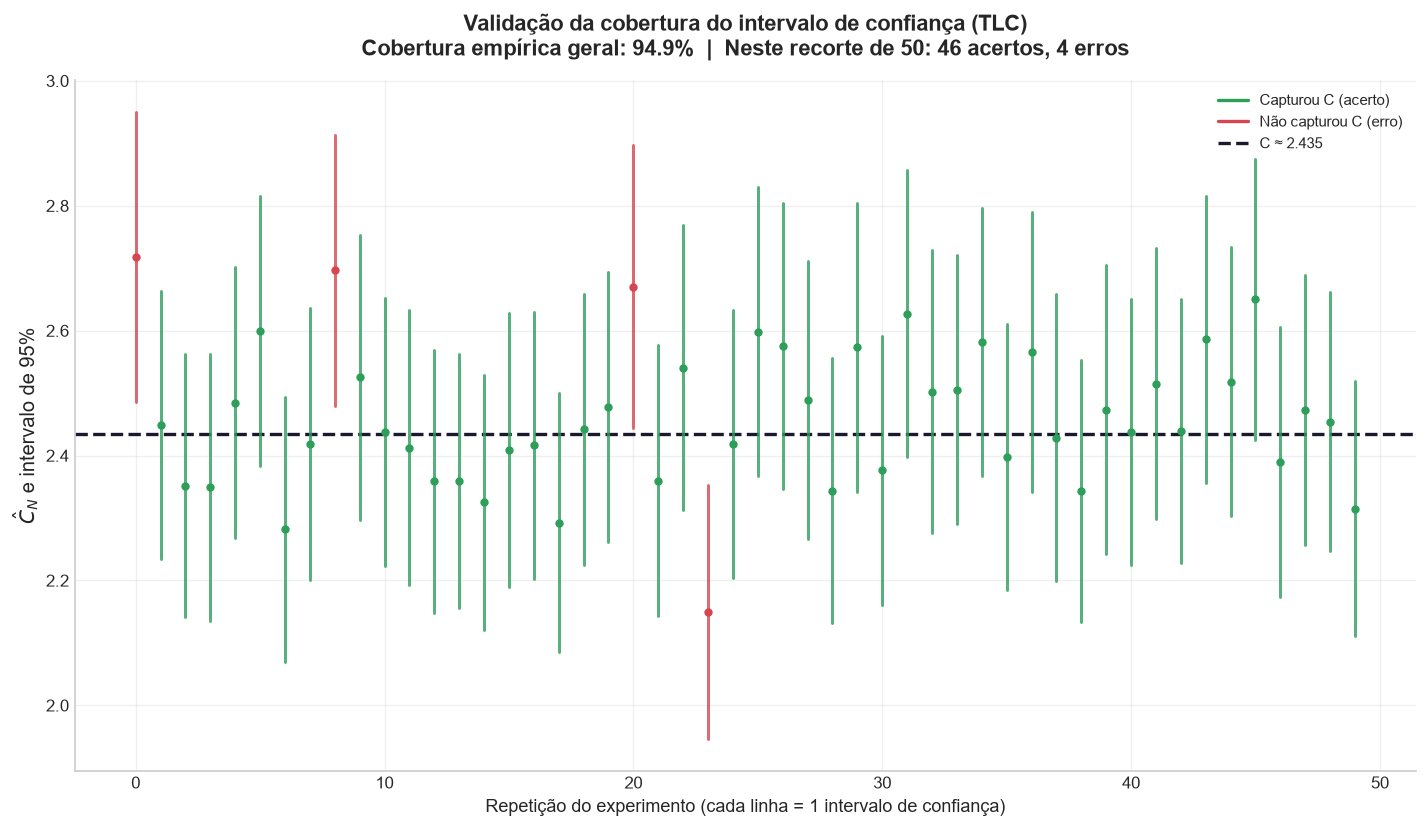

In [55]:
from matplotlib.lines import Line2D

n_mostrar = 50
subset = intervalos[:n_mostrar]

fig, ax = plt.subplots(figsize=(12, 7), dpi=120)
for idx, (estimativa, inf, sup) in enumerate(subset):
    capturou = inf <= C <= sup
    cor = '#2E9E5B' if capturou else '#D64550'
    ax.plot([idx, idx], [inf, sup], color=cor, linewidth=1.8, alpha=0.8, zorder=2)
    ax.plot(idx, estimativa, 'o', color=cor, markersize=4, zorder=3)

ax.axhline(y=C, color='#1A1A2E', linestyle='--', linewidth=2,
           label=f'Preço teórico (C ≈ {C:.3f})', zorder=1)

erros = sum(1 for (est, inf, sup) in subset if not (inf <= C <= sup))
ax.set_xlabel('Repetição do experimento (cada linha = 1 intervalo de confiança)', fontsize=11)
ax.set_ylabel(r'$\hat{C}_N$ e intervalo de 95%', fontsize=12)
ax.set_title(f'Validação da cobertura do intervalo de confiança (TLC)\n'
             f'Cobertura empírica geral: {cobertura_empirica*100:.1f}%  |  '
             f'Neste recorte de {n_mostrar}: {n_mostrar - erros} acertos, {erros} erros',
             fontsize=13, fontweight='bold', pad=15)

legend_elements = [
    Line2D([0], [0], color='#2E9E5B', lw=2, label='Capturou C (acerto)'),
    Line2D([0], [0], color='#D64550', lw=2, label='Não capturou C (erro)'),
    Line2D([0], [0], color='#1A1A2E', lw=2, linestyle='--', label=f'C ≈ {C:.3f}')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Módulo 4 — Convergência do Binomial para Black–Scholes

O modelo binomial converge para o modelo de **Black–Scholes** conforme $n_{steps} \to \infty$. 

A fórmula fechada de Black–Scholes para uma call europeia:

$$C_{BS} = S_0\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2), \qquad
d_1 = \frac{\ln(S_0/K) + (r + \tfrac{\sigma^2}{2})T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

In [56]:
def preco_binomial(N):
    delta = T / N
    us = M.exp(dp_anual * M.sqrt(delta))
    md_ = 1 / us
    mp = (M.exp(r * delta) - md_) / (us - md_)

    hope = 0
    for t in range(N + 1):
        probt = binom.pmf(t, N, mp)
        Snt = s0 * (us ** t) * (md_ ** (N - t))
        hope += probt * max(Snt - strike, 0)
    return M.exp(-r * T) * hope

def black_scholes():
    d1 = (M.log(s0 / strike) + (r + (dp_anual ** 2) / 2) * T) / (dp_anual * M.sqrt(T))
    d2 = d1 - dp_anual * M.sqrt(T)
    return s0 * norm.cdf(d1) - strike * M.exp(-r * T) * norm.cdf(d2)

print(f"Binomial (N=10):   {preco_binomial(10):.4f}")
print(f"Binomial (N=500):  {preco_binomial(500):.4f}")
print(f"Black-Scholes:     {black_scholes():.4f}")

Binomial (N=10):   2.4044
Binomial (N=500):  2.4345
Black-Scholes:     2.4336


### Gráfico — o Binomial converge para Black–Scholes

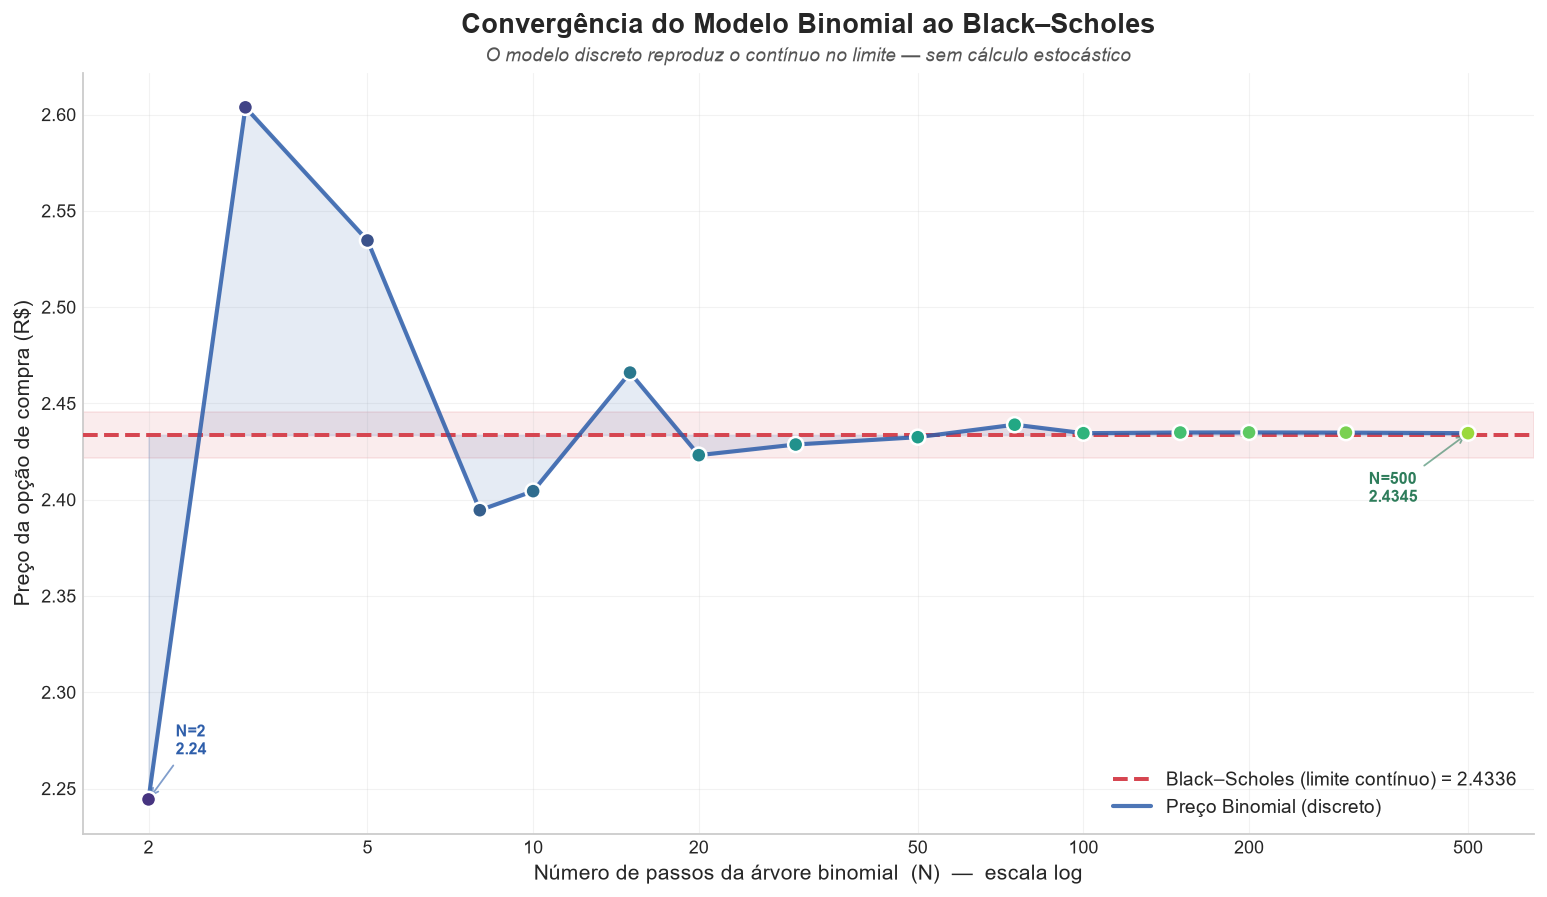

In [57]:
valores_N = [2, 3, 5, 8, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300, 500]
precos_bin = [preco_binomial(N) for N in valores_N]
preco_bs = black_scholes()

fig, ax = plt.subplots(figsize=(12, 7), dpi=130)

tolerancia = preco_bs * 0.005
ax.axhspan(preco_bs - tolerancia, preco_bs + tolerancia, color='#D64550', alpha=0.10, zorder=0)
ax.fill_between(valores_N, precos_bin, preco_bs, color='#2E5EAA', alpha=0.12, zorder=1)
ax.axhline(y=preco_bs, color='#D64550', linestyle='--', linewidth=2.2,
           label=f'Black–Scholes (limite contínuo) = {preco_bs:.4f}', zorder=3)

cores_pontos = plt.cm.viridis(np.linspace(0.15, 0.85, len(valores_N)))
ax.plot(valores_N, precos_bin, linewidth=2.3, color='#2E5EAA', alpha=0.85, zorder=4,
        label='Preço Binomial (discreto)')
ax.scatter(valores_N, precos_bin, s=70, c=cores_pontos, edgecolors='white',
           linewidths=1.4, zorder=5)

ax.annotate(f'N={valores_N[0]}\n{precos_bin[0]:.2f}', xy=(valores_N[0], precos_bin[0]),
            xytext=(15, 25), textcoords='offset points', fontsize=9, fontweight='bold',
            color='#2E5EAA', arrowprops=dict(arrowstyle='->', color='#2E5EAA', alpha=0.6))
ax.annotate(f'N={valores_N[-1]}\n{precos_bin[-1]:.4f}', xy=(valores_N[-1], precos_bin[-1]),
            xytext=(-55, -38), textcoords='offset points', fontsize=9, fontweight='bold',
            color='#2E7D5B', arrowprops=dict(arrowstyle='->', color='#2E7D5B', alpha=0.6))

ax.set_xscale('log')
ax.set_xlabel('Número de passos da árvore binomial  (N)  —  escala log', fontsize=11.5)
ax.set_ylabel('Preço da opção de compra (R$)', fontsize=11.5)
ax.set_title('Convergência do Modelo Binomial ao Black–Scholes', fontsize=15, fontweight='bold', pad=22)
ax.text(0.5, 1.015, 'O modelo discreto reproduz o contínuo no limite — sem cálculo estocástico',
        transform=ax.transAxes, ha='center', fontsize=10.5, color='#555555', style='italic')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.legend(loc='lower right', fontsize=10.5, framealpha=0.95, edgecolor='#DDDDDD', fancybox=True)
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.6)
ax.set_xticks([2, 5, 10, 20, 50, 100, 200, 500])
ax.set_xticklabels(['2', '5', '10', '20', '50', '100', '200', '500'])
plt.tight_layout()
plt.show()